<a href="https://colab.research.google.com/github/luiseduaardo/ml-ds/blob/main/supervised-learning/regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
import pandas as pd

df = pd.read_csv("../data/housing/housing.csv")
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
211,4900000,12900,3,1,1,yes,no,no,no,no,2,no,furnished
174,5250000,3800,3,1,2,yes,yes,yes,no,no,1,yes,unfurnished
112,6083000,4300,6,2,2,yes,no,no,no,no,0,no,furnished
323,4025000,5400,3,1,1,yes,no,no,no,no,3,no,semi-furnished
362,3710000,4050,2,1,1,yes,no,no,no,no,0,no,furnished
291,4200000,2953,3,1,2,yes,no,yes,no,yes,0,no,unfurnished
290,4200000,2610,4,3,2,no,no,no,no,no,0,no,semi-furnished
127,5880000,6500,3,2,3,yes,no,no,no,yes,0,no,unfurnished
352,3780000,5830,2,1,1,yes,no,no,no,no,2,no,unfurnished
421,3360000,4750,2,1,1,yes,no,no,no,no,0,no,unfurnished


### Pré processamento

In [117]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [118]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, dtype=int)
colunas_ohe = ['furnishingstatus']

matriz_ohe = ohe.fit_transform(df[colunas_ohe])
colunas = ohe.get_feature_names_out(colunas_ohe)

df_ohe = pd.DataFrame(matriz_ohe, columns=colunas, index=df.index)

df = pd.concat([df, df_ohe], axis=1).drop(columns=colunas_ohe)

In [119]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [120]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Inferência

In [122]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
predictions = model.predict(X_test_scaled)

/home/user/anaconda3/envs/env_mlds/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [124]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import sqrt

mae = mean_absolute_error(Y_test, predictions)
rmse = sqrt(mean_squared_error(Y_test, predictions))

print(f"Coefciente de determinação (R²): {model.score(X_train, Y_train):.2f}")
print(f"Root-Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Coefciente de determinação (R²): 0.69
Root-Mean Squared Error: 1324506.96
Mean Absolute Error: 970043.40


### Interpretação dos Coeficientes

Os coeficientes indicam a influência de cada feature na predição:
- **Coeficiente positivo**: Quanto maior o valor da feature, maior a probabilidade de preço alto
- **Coeficiente negativo**: Quanto maior o valor da feature, menor a probabilidade de preço alto
- **Magnitude (valor absoluto)**: Maior magnitude = maior influência na predição

In [125]:
comp = pd.DataFrame({'parametro': df.columns[1:], "coefciente": model.coef_})
comp

,parametro,coefciente
0,area,519552.416340
1,bedrooms,57349.559419
2,bathrooms,521879.027748
3,stories,349251.438906
4,mainroad,128498.628215
5,guestroom,88768.667686
6,basement,187067.803214
7,hotwaterheating,149862.702991
8,airconditioning,365157.393851
9,parking,192005.953667


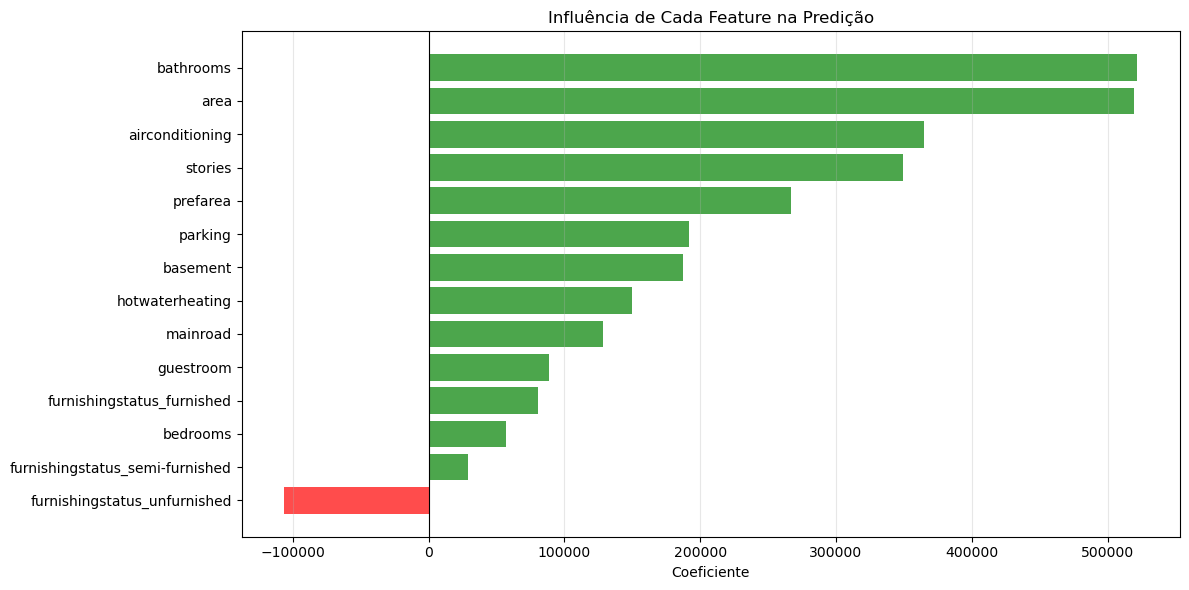

In [126]:
# Visualização dos coeficientes
fig, ax = plt.subplots(1, figsize=(12, 6))

comp_sorted = comp.sort_values('coefciente')

colors = ['red' if x < 0 else 'green' for x in comp_sorted['coefciente']]
ax.barh(comp_sorted['parametro'], comp_sorted['coefciente'], color=colors, alpha=0.7)
ax.set_xlabel('Coeficiente')
ax.set_title('Influência de Cada Feature na Predição')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Aplicando a regularização Ridge e Lasso

In [127]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np

In [128]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test_scaled)

print("=== RIDGE REGRESSION ===")
print(f'MAE: {mean_absolute_error(Y_test, ridge_pred):.4f}')
print(f'MSE: {mean_squared_error(Y_test, ridge_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(Y_test, ridge_pred)):.4f}')
print(f'R² (train): {ridge.score(X_train, Y_train):.4f}')
print(f'R² (test): {ridge.score(X_test, Y_test):.4f}')

=== RIDGE REGRESSION ===
MAE: 969943.1931
MSE: 1754931410491.0752
RMSE: 1324738.2423
R² (train): 0.6859
R² (test): 0.6528


/home/user/anaconda3/envs/env_mlds/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [129]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, Y_train)
lasso_pred = lasso.predict(X_test_scaled)

print("\n=== LASSO REGRESSION ===")
print(f'MAE: {mean_absolute_error(Y_test, lasso_pred):.4f}')
print(f'MSE: {mean_squared_error(Y_test, lasso_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(Y_test, lasso_pred)):.4f}')
print(f'R² (train): {lasso.score(X_train, Y_train):.4f}')
print(f'R² (test): {lasso.score(X_test, Y_test):.4f}')


=== LASSO REGRESSION ===
MAE: 970043.4089
MSE: 1754318707220.3564
RMSE: 1324506.9676
R² (train): 0.6859
R² (test): 0.6529


/home/user/anaconda3/envs/env_mlds/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [130]:
# Features selecionadas pelo Lasso (coeficientes não nulos)
print("\n=== FEATURES SELECIONADAS PELO LASSO ===")
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': lasso.coef_
})

features_selecionadas = lasso_coef[lasso_coef['Coeficiente'] != 0]
print(features_selecionadas.to_string(index=False))

num_features_removidas = len(lasso_coef) - len(features_selecionadas)
print(f"\n\nTotal de Features: {len(lasso_coef)}")
print(f"Features mantidas: {len(features_selecionadas)}")
print(f"Features removidas (coef=0): {num_features_removidas}")


=== FEATURES SELECIONADAS PELO LASSO ===
                        Feature   Coeficiente
                           area 519552.414054
                       bedrooms  57349.557092
                      bathrooms 521879.025078
                        stories 349251.432485
                       mainroad 128498.623167
                      guestroom  88768.663926
                       basement 187067.796698
                hotwaterheating 149862.692652
                airconditioning 365157.389224
                        parking 192005.949430
                       prefarea 266656.346337
     furnishingstatus_furnished 138034.252668
furnishingstatus_semi-furnished  94086.346448
   furnishingstatus_unfurnished -44927.125845


Total de Features: 14
Features mantidas: 14
Features removidas (coef=0): 0


### Comparação de desempenho

In [131]:
# Comparação dos modelos
print("\n=== COMPARAÇÃO DETALHADA ===")
comparison_df = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Ridge', 'Lasso'],
    'MAE': [
        mean_absolute_error(Y_test, predictions),
        mean_absolute_error(Y_test, ridge_pred),
        mean_absolute_error(Y_test, lasso_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(Y_test, predictions)),
        np.sqrt(mean_squared_error(Y_test, ridge_pred)),
        np.sqrt(mean_squared_error(Y_test, lasso_pred))
    ],
    'R² Train': [
        model.score(X_train, Y_train),
        ridge.score(X_train, Y_train),
        lasso.score(X_train, Y_train)
    ],
    'R² Test': [
        model.score(X_test, Y_test),
        ridge.score(X_test, Y_test),
        lasso.score(X_test, Y_test)
    ],
    'Overfitting': [
        model.score(X_train, Y_train) - model.score(X_test, Y_test),
        ridge.score(X_train, Y_train) - ridge.score(X_test, Y_test),
        lasso.score(X_train, Y_train) - lasso.score(X_test, Y_test)
    ]
})
print(comparison_df.to_string(index=False))


=== COMPARAÇÃO DETALHADA ===
           Modelo           MAE         RMSE  R² Train  R² Test  Overfitting
Linear Regression 970043.403920 1.324507e+06  0.685944 0.652924      0.03302
            Ridge 969943.193054 1.324738e+06  0.685943 0.652803      0.03314
            Lasso 970043.408899 1.324507e+06  0.685944 0.652924      0.03302
